In [1]:
!pip install pandas yfinance scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
data = yf.download("AAPL", start="2022-01-01", end="2024-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843231,179.013699,175.275678,178.710355,99310400
2022-01-05,171.165833,176.303156,170.891843,175.755177,94537600
2022-01-06,168.308502,171.537680,167.956228,168.993476,96904000
2022-01-07,168.474838,170.402559,167.359306,169.179387,86709100


In [4]:
X = data[['Open','High','Low','Volume']]
y = data['Close']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [7]:
predictions = model.predict(X_test)

predictions[:10]

array([[181.347105  ],
       [163.09013961],
       [189.6460478 ],
       [169.68047497],
       [147.11850101],
       [193.34317277],
       [189.01614845],
       [135.75155804],
       [162.88876329],
       [174.83580935]])

In [9]:
rmse = mean_squared_error(y_test, predictions) ** 0.5

print("RMSE:", rmse)

RMSE: 0.908532664471463


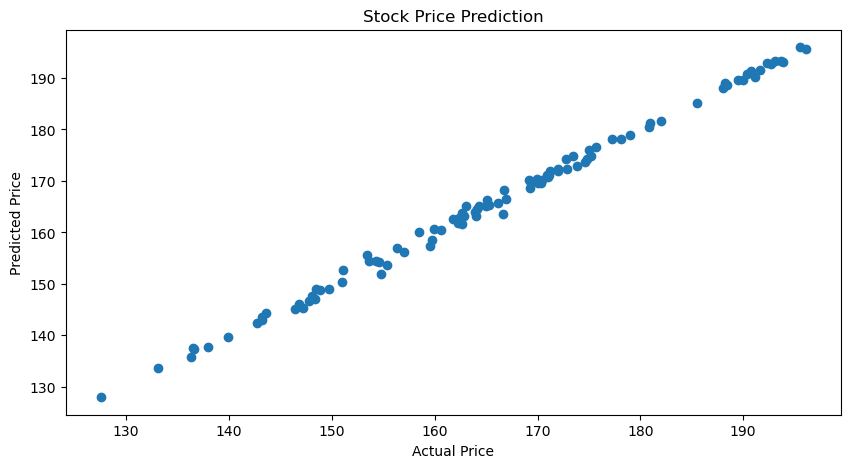

In [10]:
plt.figure(figsize=(10,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Stock Price Prediction")

plt.show()

In [11]:
data['MA20'] = data['Close'].rolling(20).mean()
data['MA50'] = data['Close'].rolling(50).mean()

In [12]:
delta = data['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss

data['RSI'] = 100 - (100 / (1 + rs))

In [13]:
data = data.dropna()

In [14]:
X = data[['Open','High','Low','Volume','MA20','MA50','RSI']]
y = data['Close']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [17]:
predictions = model.predict(X_test)

In [18]:
rmse = mean_squared_error(y_test, predictions) ** 0.5

print("RMSE:", rmse)

RMSE: 0.7910709914404006


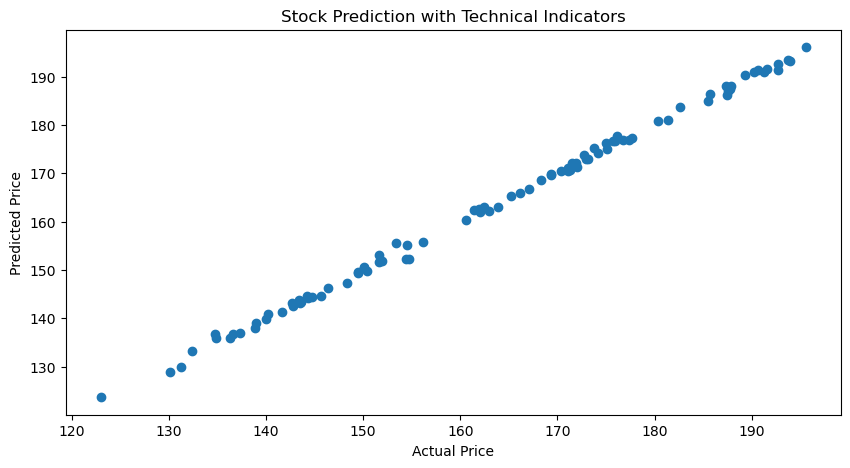

In [19]:
plt.figure(figsize=(10,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Stock Prediction with Technical Indicators")

plt.show()